In [5]:
# Step 1: Import necessary libraries and modules
# Panda for handling dataframes and numpy for handling arrays
import pandas as pd
import numpy as np

from pathlib import Path
import joblib
import json

# Load models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.svm import SVC, LinearSVC
from sklearn.cluster import KMeans

from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

# Preprocessing and Scaling modules
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler

# Preprocessing SMOTE Oversampling module 
from imblearn.over_sampling import SMOTE, KMeansSMOTE

# Max num n_jobs/processor(s) that's available for used
from joblib import cpu_count
print(f"✔️There are currently {cpu_count()} CPU-Cores available for model training💪")

# Load evaluation metrics
from sklearn.metrics import(
    confusion_matrix, 
    classification_report,
    confusion_matrix, 
    roc_auc_score,
    recall_score,
    accuracy_score,
    precision_score,
    f1_score
)
 
# Import modules for data manipulation
from sklearn.model_selection import train_test_split, RandomizedSearchCV, GridSearchCV
import matplotlib.pyplot as plt
import seaborn as sns

✔️There are currently 8 CPU-Cores available for model training💪


In [7]:
# ------------------------------------------------------------
# Project paths
# ------------------------------------------------------------
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

ARTIFACTS_DIR = PROJECT_ROOT / "artifacts"
MODELS_DIR = ARTIFACTS_DIR / "models"
METRICS_DIR = ARTIFACTS_DIR / "metrics"

MODELS_DIR.mkdir(parents=True, exist_ok=True)
METRICS_DIR.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Models dir:", MODELS_DIR)
print("Metrics dir:", METRICS_DIR)

# ------------------------------------------------------------
# Helper function
# ------------------------------------------------------------
def extract_fraud_metrics(model_name, y_true, y_pred, workflow):
    """
    Extract fraud-class precision, recall, and F1 from predictions.
    """
    return {
        "model_name": model_name,
        "workflow": workflow,
        "precision_fraud": precision_score(y_true, y_pred, pos_label=1, zero_division=0),
        "recall_fraud": recall_score(y_true, y_pred, pos_label=1, zero_division=0),
        "f1_fraud": f1_score(y_true, y_pred, pos_label=1, zero_division=0)
    }

Project root: c:\Users\oneps\Documents\DataEden_Github\fari-tech-portfolio\applied-data-science-machine-learning\ml-fraud-detection
Models dir: c:\Users\oneps\Documents\DataEden_Github\fari-tech-portfolio\applied-data-science-machine-learning\ml-fraud-detection\artifacts\models
Metrics dir: c:\Users\oneps\Documents\DataEden_Github\fari-tech-portfolio\applied-data-science-machine-learning\ml-fraud-detection\artifacts\metrics


In [4]:
#Step 2:  Load data as pandas dataframe 
# Baseline transactions 
df_baseline = pd.read_csv("../data/baseline_transacts.csv")

# Baseline dummy encoding transform
df_base_dummy_encode = pd.read_csv("../data/baseline_dummy_encode_transacts.csv")

# Log feature transform
df_log_transacts = pd.read_csv("../data/log_transacts.csv")

# Log and dummy encoding transforms
df_log_dummy_encode_transacts = pd.read_csv("../data/log_dummy_encode_transacts.csv")


# Log, change in transaction, and dummy encoding transforms
df_log_diff_dummy_encode = pd.read_csv("../data/log_diff_dummy_transacts.csv")


In [18]:
# Training without SMOTE and using log normalization on predictors
# Step 3.1: Separate features (X) and target (y)
X = df_log_diff_dummy_encode.drop(columns=['isFraud'])  # All features except target
y = df_log_diff_dummy_encode['isFraud']                 # Target variable

# Step 3.2: Split into training and testing sets
# Use stratify=y to keep the fraud/non-fraud ratio consistent, but I think could be redundant when using SMOTE??
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [6]:
# without using SMOTE
# Scale training and testing data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test) # Apply same scaler to test set

# Print output from training
print("✅ Data pre-processing complete: features scaled.\n", X_train_scaled)
print("\n✅ Data pre-processing complete: test data scaled.\n", X_test_scaled)


✅ Data pre-processing complete: features scaled.
 [[-0.73565498 -0.08327825 -0.71638167 ...  0.09354458 -0.14233443
  -1.14741344]
 [ 1.35933287 -0.08327825 -0.71638167 ...  0.11634656 -0.14228997
   0.87152544]
 [-0.73565498 -0.08327825 -0.71638167 ...  0.11634656  3.92743105
   0.87152544]
 ...
 [-0.73565498 -0.08327825  1.39590395 ...  0.099119   -0.14231597
   0.87152544]
 [ 1.35933287 -0.08327825 -0.71638167 ...  0.11634656  0.12999653
   0.87152544]
 [-0.73565498 -0.08327825 -0.71638167 ... -0.71870966 -0.1423015
  -1.14741344]]

✅ Data pre-processing complete: test data scaled.
 [[-0.73565498 -0.08327825 -0.71638167 ... -0.01690802 -0.14233443
  -1.14741344]
 [-0.73565498 -0.08327825 -0.71638167 ...  0.11634656 -0.14232477
   0.87152544]
 [ 1.35933287 -0.08327825 -0.71638167 ...  0.11634656 -0.14225037
   0.87152544]
 ...
 [-0.73565498 -0.08327825  1.39590395 ...  0.10026392 -0.14227453
   0.87152544]
 [ 1.35933287 -0.08327825 -0.71638167 ...  0.11634656  0.85778997
   0.8715254

In [ ]:
# ------------------------------------------------------------
# Step 6: Hyperparameter search grids
# Workflow: No SMOTE
# ------------------------------------------------------------
param_grids = {
    "Random Forest": {
        "n_estimators": [100, 200, 400],
        "criterion": ["gini", "entropy", "log_loss"],
        "max_depth": list(range(10, 55, 5)),
        "max_features": ["sqrt", "log2"],
        "min_samples_split": [2, 5, 20]
    },
    "AdaBoost": {
        "n_estimators": [50, 100, 200],
        "learning_rate": [0.01, 0.1, 0.5, 1.0],
        "estimator__max_depth": [1, 2, 3],
        "estimator__min_samples_split": [2, 5, 10],
        "estimator__min_samples_leaf": [1, 2, 4]
    },
    "Logistic Reg": {
        "C": np.logspace(-3, 3, 7),
        "penalty": ["l1", "l2"],
        "solver": ["saga"],
        "max_iter": [500, 1000, 5000]
    },
    "KNN": {
        "n_neighbors": [3, 5, 7, 11],
        "weights": ["uniform", "distance"],
        "p": [1, 2],
        "leaf_size": [20, 30, 50],
        "algorithm": ["auto"]
    }
}


In [ ]:

# ------------------------------------------------------------
# Step 6: Define classifiers
# ------------------------------------------------------------
models = {
    "Random Forest": RandomForestClassifier(class_weight="balanced", random_state=42),
    "AdaBoost": AdaBoostClassifier(
        estimator=DecisionTreeClassifier(random_state=42),
        random_state=42
    ),
    "Logistic Reg": LogisticRegression(
        solver="saga",
        class_weight="balanced",
        random_state=42
    ),
    "KNN": KNeighborsClassifier()
} 
best_models = {}
best_params_store = {}
prediction_rows = []
results_rows = []

workflow_name = "No SMOTE"

for name, model in models.items():
    print(f"\n🔥 Training and tuning: {name}")

    param_grid = param_grids[name]

    random_search = RandomizedSearchCV(
        estimator=model,
        param_distributions=param_grid,
        n_iter=10,          
        cv=5,
        scoring="f1",
        random_state=42,
        n_jobs=-1
    )

    # Train
    random_search.fit(X_train_scaled, y_train)

    # Store best fitted model
    best_model = random_search.best_estimator_
    best_models[name] = best_model
    best_params_store[name] = random_search.best_params_

    # Save trained model immediately
    safe_name = name.lower().replace(" ", "_")
    model_path = MODELS_DIR / f"{safe_name}_best_model.joblib"
    joblib.dump(best_model, model_path)

    # Predict class labels
    yhat = best_models[name].predict(X_test_scaled)

    # Predict probabilities when supported
    if hasattr(best_model, "predict_proba"):
        yhat_proba = best_model.predict_proba(X_test_scaled)[:, 1]  # type: ignore[attr-defined]
        auc = roc_auc_score(y_test, yhat_proba)
    else:
        yhat_proba = [None] * len(y_test)
        auc = roc_auc_score(y_test, yhat)

    # Evaluate
    cm = confusion_matrix(y_test, yhat)
    tn, fp, fn, tp = cm.ravel()
    report = classification_report(y_test, yhat, digits=3, zero_division=0)

    print(f"✅ Best Parameters for {name}:\n", random_search.best_params_)
    print("📊 Confusion Matrix:\n", cm)
    print("📋 Classification Report:\n", report)
    print(f"🎯 ROC-AUC Score: {auc:.4f}")

    # Save fraud-class summary row
    row = extract_fraud_metrics(
        model_name=name,
        y_true=y_test,
        y_pred=yhat,
        workflow=workflow_name
    )
    row["roc_auc"] = float(auc)
    row["tn"] = int(tn)
    row["fp"] = int(fp)
    row["fn"] = int(fn)
    row["tp"] = int(tp)

    results_rows.append(row)

    # Save prediction-level rows for later analysis / visuals
    for true_val, pred_val, proba_val in zip(y_test, yhat, yhat_proba):
        prediction_rows.append({
            "model_name": name,
            "workflow": workflow_name,
            "y_true": int(true_val),
            "y_pred": int(pred_val),
            "y_pred_proba": None if proba_val is None else float(proba_val)
        })


🔥 Training and tuning: Random Forest
✅ Best Parameters for Random Forest:
 {'n_estimators': 100, 'min_samples_split': 20, 'max_features': 'sqrt', 'max_depth': 35, 'criterion': 'log_loss'}
📊 Confusion Matrix:
 [[19974     0]
 [    0    26]]
📋 Classification Report:
               precision    recall  f1-score   support

           0      1.000     1.000     1.000     19974
           1      1.000     1.000     1.000        26

    accuracy                          1.000     20000
   macro avg      1.000     1.000     1.000     20000
weighted avg      1.000     1.000     1.000     20000

🎯 ROC-AUC Score: 1.0000

🔥 Training and tuning: AdaBoost
✅ Best Parameters for AdaBoost:
 {'n_estimators': 200, 'learning_rate': 0.1, 'estimator__min_samples_split': 10, 'estimator__min_samples_leaf': 1, 'estimator__max_depth': 2}
📊 Confusion Matrix:
 [[19973     1]
 [    0    26]]
📋 Classification Report:
               precision    recall  f1-score   support

           0      1.000     1.000     1.00

c:\Users\oneps\anaconda3\envs\ml-hands\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


✅ Best Parameters for Logistic Reg:
 {'solver': 'saga', 'penalty': 'l2', 'max_iter': 5000, 'C': np.float64(10.0)}
📊 Confusion Matrix:
 [[19440   534]
 [    1    25]]
📋 Classification Report:
               precision    recall  f1-score   support

           0      1.000     0.973     0.986     19974
           1      0.045     0.962     0.085        26

    accuracy                          0.973     20000
   macro avg      0.522     0.967     0.536     20000
weighted avg      0.999     0.973     0.985     20000

🎯 ROC-AUC Score: 0.9967

🔥 Training and tuning: KNN
✅ Best Parameters for KNN:
 {'weights': 'uniform', 'p': 1, 'n_neighbors': 5, 'leaf_size': 20, 'algorithm': 'auto'}
📊 Confusion Matrix:
 [[19973     1]
 [    9    17]]
📋 Classification Report:
               precision    recall  f1-score   support

           0      1.000     1.000     1.000     19974
           1      0.944     0.654     0.773        26

    accuracy                          1.000     20000
   macro avg      

In [ ]:
# ------------------------------------------------------------
# Save summary outputs from No SMOTE workflow
# ------------------------------------------------------------
results_df = pd.DataFrame(results_rows)
results_path = METRICS_DIR / "model_results_summary.csv"
results_df.to_csv(results_path, index=False)

predictions_df = pd.DataFrame(prediction_rows)
predictions_path = METRICS_DIR / "model_predictions_long.csv"
predictions_df.to_csv(predictions_path, index=False)

params_path = METRICS_DIR / "best_model_params.json"
with open(params_path, "w", encoding="utf-8") as f:
    json.dump(best_params_store, f, indent=2)

# Save scaler used for transformation
# Replace `scaler` below if your actual scaler variable has a different name
scaler_path = MODELS_DIR / "feature_scaler.joblib"
joblib.dump(scaler, scaler_path)

# Save all best models in one artifact
all_models_path = MODELS_DIR / "all_best_models.joblib"
joblib.dump(best_models, all_models_path)

print("\n✅ Saved summary metrics to:", results_path)
print("✅ Saved prediction-level data to:", predictions_path)
print("✅ Saved best params to:", params_path)
print("✅ Saved scaler to:", scaler_path)
print("✅ Saved all best models to:", all_models_path)

In [ ]:
# Reload no SMOTE models and metrics for later use (e.g. after notebook restart)

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

ARTIFACTS_DIR = PROJECT_ROOT / "artifacts"
MODELS_DIR = ARTIFACTS_DIR / "models"
METRICS_DIR = ARTIFACTS_DIR / "metrics"

# Load one model
rf_model = joblib.load(MODELS_DIR / "random_forest_best_model.joblib")

# Load all best models
best_models = joblib.load(MODELS_DIR / "all_best_models.joblib")

# Load scaler
scaler = joblib.load(MODELS_DIR / "feature_scaler.joblib")

# Load saved tables
results_df = pd.read_csv(METRICS_DIR / "model_results_summary.csv")
predictions_df = pd.read_csv(METRICS_DIR / "model_predictions_long.csv")

# Load saved params
with open(METRICS_DIR / "best_model_params.json", "r", encoding="utf-8") as f:
    best_params_store = json.load(f)
print(results_df.head())

      model_name  workflow  precision_fraud  recall_fraud  f1_fraud   roc_auc  \
0  Random Forest  No SMOTE         1.000000      1.000000  1.000000  1.000000   
1       AdaBoost  No SMOTE         0.962963      1.000000  0.981132  0.999998   
2   Logistic Reg  No SMOTE         0.044723      0.961538  0.085470  0.996705   
3            KNN  No SMOTE         0.944444      0.653846  0.772727  0.922817   

      tn   fp  fn  tp  
0  19974    0   0  26  
1  19973    1   0  26  
2  19440  534   1  25  
3  19973    1   9  17  


In [ ]:
# Workflow dataframe results without using SMOTE
display(results_df) 

,model_name,workflow,precision_fraud,recall_fraud,f1_fraud,roc_auc,tn,fp,fn,tp
0,Random Forest,No SMOTE,1.000000,1.000000,1.000000,1.000000,19974,0,0,26
1,AdaBoost,No SMOTE,0.962963,1.000000,0.981132,0.999998,19973,1,0,26
2,Logistic Reg,No SMOTE,0.044723,0.961538,0.085470,0.996705,19440,534,1,25
3,KNN,No SMOTE,0.944444,0.653846,0.772727,0.922817,19973,1,9,17


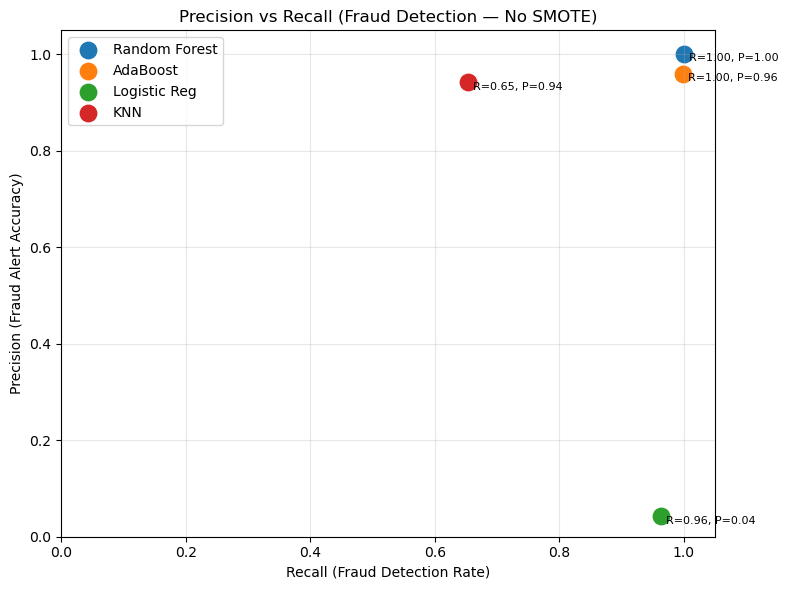

In [29]:
plt.figure(figsize=(8, 6))

seen = set()

for _, row in results_df.iterrows():
    x = row["recall_fraud"] + np.random.uniform(-0.003, 0.003)
    y = row["precision_fraud"] + np.random.uniform(-0.003, 0.003)

    label = row["model_name"] if row["model_name"] not in seen else None
    seen.add(row["model_name"])

    plt.scatter(x, y, s=140, label=label)

    plt.text(
        x + 0.008,
        y - 0.015,
        f"R={row['recall_fraud']:.2f}, P={row['precision_fraud']:.2f}",
        fontsize=8
    )

plt.title("Precision vs Recall (Fraud Detection — No SMOTE)")
plt.xlabel("Recall (Fraud Detection Rate)")
plt.ylabel("Precision (Fraud Alert Accuracy)")
plt.xlim(0, 1.05)
plt.ylim(0, 1.05)
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig("../assets/charts/model-performance-without-smote-precision-recall.png", dpi=300)
plt.show()

In [ ]:
# ------------------------------------------------------------
# Workflow: Using SMOTE
# ------------------------------------------------------------

# Step 1: Separate features and target
X = df_log_diff_dummy_encode.drop(columns=["isFraud"])
y = df_log_diff_dummy_encode["isFraud"]

# Step 2: Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Step 3: Apply SMOTE to training data only
sm = SMOTE(random_state=42)
X_resampled, y_resampled = sm.fit_resample(X_train, y_train)

# Step 4: Scale after SMOTE
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_resampled)
X_test_scaled = scaler.transform(X_test)

print("✅ SMOTE applied.")
print("📊 Class balance after SMOTE:\n", y_resampled.value_counts())
print("\n📉 y_test distribution:\n", y_test.value_counts())


✅ SMOTE applied.
📊 Class balance after SMOTE:
 isFraud
0    79896
1    79896
Name: count, dtype: int64

📉 y_test distribution:
 isFraud
0    19974
1       26
Name: count, dtype: int64

🔥 Training and tuning: Random Forest
✅ Best Parameters for Random Forest:
 {'n_estimators': 400, 'min_samples_split': 20, 'max_features': 'log2', 'max_depth': 35, 'criterion': 'log_loss'}
📊 Confusion Matrix:
 [[19974     0]
 [    0    26]]
📋 Classification Report:
               precision    recall  f1-score   support

           0      1.000     1.000     1.000     19974
           1      1.000     1.000     1.000        26

    accuracy                          1.000     20000
   macro avg      1.000     1.000     1.000     20000
weighted avg      1.000     1.000     1.000     20000

🎯 ROC-AUC Score: 1.0000

🔥 Training and tuning: AdaBoost
✅ Best Parameters for AdaBoost:
 {'n_estimators': 50, 'learning_rate': 0.1, 'estimator__min_samples_split': 2, 'estimator__min_samples_leaf': 1, 'estimator__max_dept

c:\Users\oneps\anaconda3\envs\ml-hands\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\oneps\anaconda3\envs\ml-hands\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


✅ Best Parameters for Logistic Reg:
 {'solver': 'saga', 'penalty': 'l2', 'max_iter': 1500, 'C': np.float64(10.0)}
📊 Confusion Matrix:
 [[19419   555]
 [    1    25]]
📋 Classification Report:
               precision    recall  f1-score   support

           0      1.000     0.972     0.986     19974
           1      0.043     0.962     0.083        26

    accuracy                          0.972     20000
   macro avg      0.522     0.967     0.534     20000
weighted avg      0.999     0.972     0.985     20000

🎯 ROC-AUC Score: 0.9962

🔥 Training and tuning: KNN
✅ Best Parameters for KNN:
 {'weights': 'distance', 'p': 2, 'n_neighbors': 3, 'leaf_size': 30, 'algorithm': 'auto'}
📊 Confusion Matrix:
 [[19928    46]
 [    3    23]]
📋 Classification Report:
               precision    recall  f1-score   support

           0      1.000     0.998     0.999     19974
           1      0.333     0.885     0.484        26

    accuracy                          0.998     20000
   macro avg     

In [ ]:
# ------------------------------------------------------------
# Hyperparameter grids
# ------------------------------------------------------------
param_grids = {
    "Random Forest": {
        "n_estimators": [100, 200, 400],
        "criterion": ["gini", "entropy", "log_loss"],
        "max_depth": list(range(10, 55, 5)),
        "max_features": ["sqrt", "log2"],
        "min_samples_split": [2, 5, 20]
    },
    "AdaBoost": {
        "n_estimators": [50, 100, 200],
        "learning_rate": [0.01, 0.1, 0.5, 1.0],
        "estimator__max_depth": [1, 2, 3],
        "estimator__min_samples_split": [2, 5, 10],
        "estimator__min_samples_leaf": [1, 2, 4]
    },
    "Logistic Reg": {
        "C": np.logspace(-3, 3, 7),
        "penalty": ["l1", "l2"],
        "solver": ["saga"],
        "max_iter": [500, 1000, 1500]
    },
    "KNN": {
        "n_neighbors": [3, 5, 7, 11],
        "weights": ["uniform", "distance"],
        "p": [1, 2],
        "leaf_size": [20, 30, 50],
        "algorithm": ["auto"]
    }
}


In [ ]:
# ------------------------------------------------------------
# Models
# ------------------------------------------------------------
models = {
    "Random Forest": RandomForestClassifier(class_weight="balanced", random_state=42),
    "AdaBoost": AdaBoostClassifier(
        estimator=DecisionTreeClassifier(random_state=42),
        random_state=42
    ),
    "Logistic Reg": LogisticRegression(
        solver="saga",
        class_weight="balanced",
        random_state=42
    ),
    "KNN": KNeighborsClassifier()
}

best_models = {}
best_params_store = {}
prediction_rows = []
results_rows = []

workflow_name = "SMOTE"

for name, model in models.items():
    print(f"\n🔥 Training and tuning: {name}")

    param_grid = param_grids[name]

    random_search = RandomizedSearchCV(
        estimator=model,
        param_distributions=param_grid,
        n_iter=10,
        cv=5,
        scoring="f1",
        random_state=42,
        n_jobs=-1
    )

    # Fit on SMOTE-resampled training data
    random_search.fit(X_train_scaled, y_resampled)

    best_model = random_search.best_estimator_
    best_models[name] = best_model
    best_params_store[name] = random_search.best_params_

    # Save trained model
    safe_name = name.lower().replace(" ", "_")
    model_path = MODELS_DIR / f"{safe_name}_best_model_smote.joblib"
    joblib.dump(best_model, model_path)

    # Predict labels
    yhat = best_models[name].predict(X_test_scaled)

    # Predict probabilities when supported
    if hasattr(best_model, "predict_proba"):
        yhat_proba = best_models[name].predict_proba(X_test_scaled)[:, 1]
        auc = roc_auc_score(y_test, yhat_proba)
    else:
        yhat_proba = [None] * len(y_test)
        auc = roc_auc_score(y_test, yhat)

    # Evaluate
    cm = confusion_matrix(y_test, yhat)
    tn, fp, fn, tp = cm.ravel()
    report = classification_report(y_test, yhat, digits=3, zero_division=0)

    print(f"✅ Best Parameters for {name}:\n", random_search.best_params_)
    print("📊 Confusion Matrix:\n", cm)
    print("📋 Classification Report:\n", report)
    print(f"🎯 ROC-AUC Score: {auc:.4f}")

    # Save summary row
    row = extract_fraud_metrics(
        model_name=name,
        y_true=y_test,
        y_pred=yhat,
        workflow=workflow_name
    )
    row["roc_auc"] = float(auc)
    row["tn"] = int(tn)
    row["fp"] = int(fp)
    row["fn"] = int(fn)
    row["tp"] = int(tp)

    results_rows.append(row)

    # Save prediction-level rows
    for true_val, pred_val, proba_val in zip(y_test, yhat, yhat_proba):
        prediction_rows.append({
            "model_name": name,
            "workflow": workflow_name,
            "y_true": int(true_val),
            "y_pred": int(pred_val),
            "y_pred_proba": None if proba_val is None else float(proba_val)
        })


In [ ]:
# ------------------------------------------------------------
# Save summary outputs
# ------------------------------------------------------------
results_df_smote = pd.DataFrame(results_rows)
results_path_smote = METRICS_DIR / "model_results_summary_smote.csv"
results_df_smote.to_csv(results_path_smote, index=False)

predictions_df_smote = pd.DataFrame(prediction_rows)
predictions_path_smote = METRICS_DIR / "model_predictions_long_smote.csv"
predictions_df_smote.to_csv(predictions_path_smote, index=False)

params_path_smote = METRICS_DIR / "best_model_params_smote.json"
with open(params_path_smote, "w", encoding="utf-8") as f:
    json.dump(best_params_store, f, indent=2)

scaler_path_smote = MODELS_DIR / "feature_scaler_smote.joblib"
joblib.dump(scaler, scaler_path_smote)

all_models_path_smote = MODELS_DIR / "all_best_models_smote.joblib"
joblib.dump(best_models, all_models_path_smote)

print("\n✅ Saved SMOTE summary metrics to:", results_path_smote)
print("✅ Saved SMOTE prediction-level data to:", predictions_path_smote)
print("✅ Saved SMOTE best params to:", params_path_smote)
print("✅ Saved SMOTE scaler to:", scaler_path_smote)
print("✅ Saved SMOTE all best models to:", all_models_path_smote)

In [15]:
# Reload SMOTE models and metrics for later use (e.g. after notebook restart)

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

ARTIFACTS_DIR = PROJECT_ROOT / "artifacts"
MODELS_DIR = ARTIFACTS_DIR / "models"
METRICS_DIR = ARTIFACTS_DIR / "metrics"

# Load one model
rf_model = joblib.load(MODELS_DIR / "random_forest_best_model_smote.joblib")

# Load all best models
best_models = joblib.load(MODELS_DIR / "all_best_models_smote.joblib")

# Load scaler
scaler = joblib.load(MODELS_DIR / "feature_scaler_smote.joblib")

# Load saved tables
smote_results_df = pd.read_csv(METRICS_DIR / "model_results_summary_smote.csv")
predictions_df = pd.read_csv(METRICS_DIR / "model_predictions_long_smote.csv")

# Load saved params
with open(METRICS_DIR / "best_model_params_smote.json", "r", encoding="utf-8") as f:
    best_params_store = json.load(f)
print(smote_results_df.head())


      model_name workflow  precision_fraud  recall_fraud  f1_fraud   roc_auc  \
0  Random Forest    SMOTE         1.000000      1.000000  1.000000  1.000000   
1       AdaBoost    SMOTE         0.962963      1.000000  0.981132  0.999973   
2   Logistic Reg    SMOTE         0.043103      0.961538  0.082508  0.996237   
3            KNN    SMOTE         0.333333      0.884615  0.484211  0.960574   

      tn   fp  fn  tp  
0  19974    0   0  26  
1  19973    1   0  26  
2  19419  555   1  25  
3  19928   46   3  23  


In [16]:
# Workflow dataframe results using SMOTE 
display(smote_results_df)

,model_name,workflow,precision_fraud,recall_fraud,f1_fraud,roc_auc,tn,fp,fn,tp
0,Random Forest,SMOTE,1.000000,1.000000,1.000000,1.000000,19974,0,0,26
1,AdaBoost,SMOTE,0.962963,1.000000,0.981132,0.999973,19973,1,0,26
2,Logistic Reg,SMOTE,0.043103,0.961538,0.082508,0.996237,19419,555,1,25
3,KNN,SMOTE,0.333333,0.884615,0.484211,0.960574,19928,46,3,23


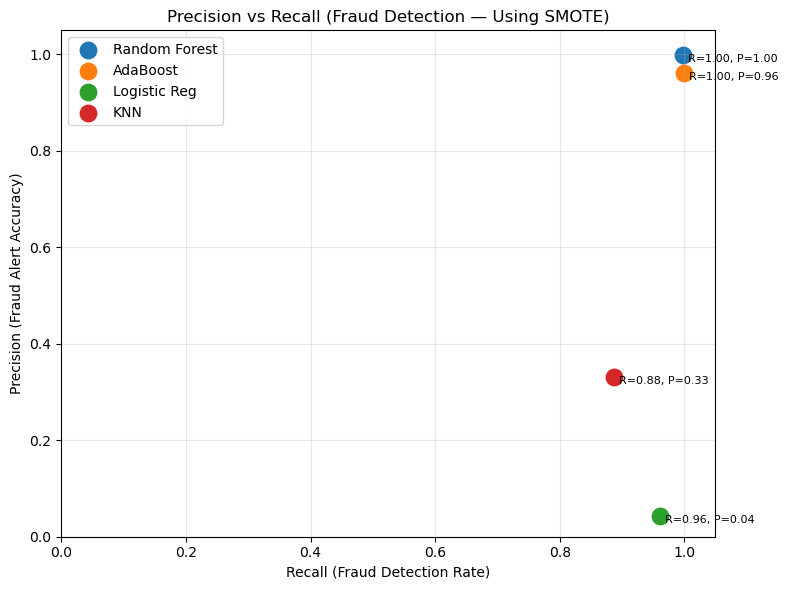

In [17]:
plt.figure(figsize=(8, 6))

seen = set()

for _, row in smote_results_df.iterrows():
    x = row["recall_fraud"] + np.random.uniform(-0.003, 0.003)
    y = row["precision_fraud"] + np.random.uniform(-0.003, 0.003)

    label = row["model_name"] if row["model_name"] not in seen else None
    seen.add(row["model_name"])

    plt.scatter(x, y, s=140, label=label)

    plt.text(
        x + 0.008,
        y - 0.015,
        f"R={row['recall_fraud']:.2f}, P={row['precision_fraud']:.2f}",
        fontsize=8
    )

plt.title("Precision vs Recall (Fraud Detection — Using SMOTE)")
plt.xlabel("Recall (Fraud Detection Rate)")
plt.ylabel("Precision (Fraud Alert Accuracy)")
plt.xlim(0, 1.05)
plt.ylim(0, 1.05)
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig("../assets/charts/model-performance-smote-precision-recall.png", dpi=300)
plt.show()

In [9]:
# ------------------------------------------------------------
# Reload saved metrics for plotting
# ------------------------------------------------------------
results_no_smote = pd.read_csv(METRICS_DIR / "model_results_summary.csv")
results_smote = pd.read_csv(METRICS_DIR / "model_results_summary_smote.csv")

results_all = pd.concat([results_no_smote, results_smote], ignore_index=True)

display(results_all)

,model_name,workflow,precision_fraud,recall_fraud,f1_fraud,roc_auc,tn,fp,fn,tp
0,Random Forest,No SMOTE,1.000000,1.000000,1.000000,1.000000,19974,0,0,26
1,AdaBoost,No SMOTE,0.962963,1.000000,0.981132,0.999998,19973,1,0,26
2,Logistic Reg,No SMOTE,0.044723,0.961538,0.085470,0.996705,19440,534,1,25
3,KNN,No SMOTE,0.944444,0.653846,0.772727,0.922817,19973,1,9,17
4,Random Forest,SMOTE,1.000000,1.000000,1.000000,1.000000,19974,0,0,26
5,AdaBoost,SMOTE,0.962963,1.000000,0.981132,0.999973,19973,1,0,26
6,Logistic Reg,SMOTE,0.043103,0.961538,0.082508,0.996237,19419,555,1,25
7,KNN,SMOTE,0.333333,0.884615,0.484211,0.960574,19928,46,3,23


In [20]:
print(results_all["workflow"].unique())

<StringArray>
['No SMOTE', 'SMOTE']
Length: 2, dtype: str


In [19]:
# Step 2: Apply SMOTE to training data only
sm = SMOTE(random_state=42)
X_resampled, y_resampled = sm.fit_resample(X_train, y_train)

# Step 3: Scale features after SMOTE
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_resampled)
X_test_scaled = scaler.transform(X_test)

# Step 4: Show class balance and test skew
print("✅ SMOTE applied.")
print("📊 Class balance after SMOTE:\n", y_resampled.value_counts())
print("\n📉 y_test distribution:\n", y_test.value_counts())

✅ SMOTE applied.
📊 Class balance after SMOTE:
 isFraud
0    79896
1    79896
Name: count, dtype: int64

📉 y_test distribution:
 isFraud
0    19974
1       26
Name: count, dtype: int64


In [ ]:
# Step 6: hyperparameter Search Grids
# With SMOTE 
param_grids = {
    "Random Forest": {
        "n_estimators": [100, 200, 400],                # Number of trees in the forest
        "criterion": ["gini", "entropy", "log_loss"],   # Function to measure the quality of a split
        "max_depth": range(10, 55, 5),                  # Maximum depth of each tree
        "max_features": ["sqrt", "log2"],               # Number of features to consider at each split
        "min_samples_split": [2, 5, 20]                 # Minimum number of samples to split an internal node
    },
    "AdaBoost": {
        "n_estimators": [50, 100, 200],                 # Number of boosting rounds
        "learning_rate": [0.01, 0.1, 0.5, 1.0],         # Shrinks the contribution of each classifier
        "estimator__max_depth": [1, 2, 3],              # Controls weak learner complexity
        "estimator__min_samples_split": [2, 5, 10],     # Regularization
        "estimator__min_samples_leaf": [1, 2, 4]        # Minimum samples required at a leaf node
    },
    "Logistic Reg": {
        "C": np.logspace(-3, 3, 7),                     # Inverse of regularization strength
        "penalty": ["l1", "l2"],                        # Type of regularization to apply
        "solver": ["saga"],                             # Optimizer that supports L1/L2 with large data
        "max_iter": [500, 1000, 1500],                  # Max number of iterations for convergence
    },
    "KNN": {
        "n_neighbors": [3, 5, 7, 11],                   # Number of neighbors to use for prediction
        "weights": ["uniform", "distance"],             # Uniform: equal weights, Distance: closer = more weight
        "p": [1, 2],                                     # Distance metric: 1 = Manhattan, 2 = Euclidean
        "leaf_size": [20, 30, 50],                      # Leaf size for tree-based algorithms
        "algorithm": ["auto"]                           # Algorithm used to compute nearest neighbors
    }
}


In [ ]:
# Step 6: Define classifiers for training
# With SMOTE
models = {
    "Random Forest": RandomForestClassifier(class_weight='balanced', random_state=42),
    "AdaBoost": AdaBoostClassifier(estimator=DecisionTreeClassifier(random_state=42), random_state=42),
    "Logistic Reg": LogisticRegression(solver='saga', class_weight='balanced', random_state=42),
    "KNN": KNeighborsClassifier()
}

# Store best models 
best_models = {}

# Select models for training and tuning
for name, model in models.items():
    print(f"\n🔥 Training and tuning: {name}")
    
    param_grid = param_grids[name] # Select which param to use in randomized search
    
    random_search = RandomizedSearchCV(
        model,
        param_distributions=param_grid,
        #n_iter=10,      # Tuning param
        cv=5,
        scoring='f1',    # Scoring param, maybe I can also try 'roc_auc'??
        random_state=42,
        n_jobs=-1        # Number of CPU-Cores param 
    )
    
    # Fit to training data
    random_search.fit(X_train_scaled, y_resampled)
    
    # Save the best model
    best_models[name] = random_search.best_estimator_

    # Predict on test set using the best model
    yhat = best_models[name].predict(X_test_scaled)

    # Evaluate
    cm = confusion_matrix(y_test, yhat)
    report = classification_report(y_test, yhat, digits=3, zero_division=0)
    auc = roc_auc_score(y_test, yhat)
    
    print(f"✅ Best Parameters for {name}:\n", random_search.best_params_)
    print("📊 Confusion Matrix:\n", cm)
    print("📋 Classification Report:\n", report)
    print(f"🎯 ROC-AUC Score: {auc:.4f}")
    
    # Extract fraud-class metrics for later plotting/table output
    row = extract_fraud_metrics(
        model_name=name,
        y_true=y_test,
        y_pred=yhat,
        workflow="No SMOTE"
    )
    results_rows.append(row)

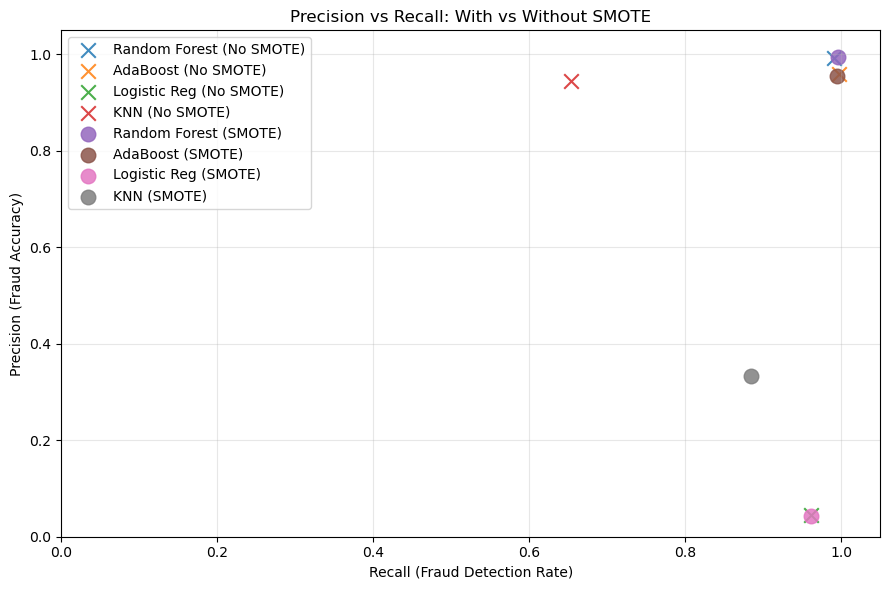

In [28]:
plt.figure(figsize=(9, 6))

seen = set()

for _, row in results_all.iterrows():
    x = row["recall_fraud"]
    y = row["precision_fraud"]

    model = row["model_name"]
    workflow = row["workflow"]

    marker = "x" if workflow == "No SMOTE" else "o"

    label = f"{model} ({workflow})"
    display_label = label if label not in seen else None
    seen.add(label)

    # Optional: small jitter ONLY for overlapping cluster
    if x > 0.95 and y > 0.95:
        x += np.random.uniform(-0.01, 0.0)
        y += np.random.uniform(-0.01, 0.0)

    plt.scatter(
        x,
        y,
        s=110,
        marker=marker,
        alpha=0.85,
        label=display_label
    )

plt.title("Precision vs Recall: With vs Without SMOTE")
plt.xlabel("Recall (Fraud Detection Rate)")
plt.ylabel("Precision (Fraud Accuracy)")

plt.xlim(0, 1.05)
plt.ylim(0, 1.05)

plt.grid(alpha=0.3)

# Legend on LEFT
plt.legend(loc="upper left")

plt.tight_layout()
plt.savefig("../assets/charts/model-performance-smote-vs-no-smote.png", dpi=300)
plt.show()